In [2]:
import pandas as pd
from pathlib import Path
from neural_priors.utils.data import Subject, get_all_subject_ids, get_all_behavioral_data
from neural_priors.encoding_model2.decode import get_decoding_paradigm
import numpy as np
from tqdm.notebook import tqdm
from tqdm.contrib.itertools import product
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt

bids_folder = Path('/data/ds-neuralpriors')

model_label = 31
spherical_noise = False


def get_pdf(subject, smoothed=False, model_label=31, fit_responses=False, n_voxels=100, spherical_noise=False):
    # Load subject
    sub = Subject(subject, bids_folder=bids_folder)

    # Create target folder
    key = f'model{model_label}'

    if smoothed:
        key += '.smoothed'

    if spherical_noise:
        key += '.spherical_noise'

    if fit_responses:
        key += '.fit_responses'

    target_dir = bids_folder / 'derivatives' / 'decoding2' / key / f'sub-{subject}' / 'func'

    # sub-04_mask-NPCr_nvoxels-100_pars.tsv
    pdf = pd.read_csv(target_dir / f'sub-{subject}_mask-NPCr_nvoxels-{n_voxels}_pars.tsv', sep='\t', index_col=[0,1], header=[0,1], )
    paradigm = get_decoding_paradigm(sub, fit_responses=fit_responses, drop_levels=False)
    pdf.index = paradigm.index

    pdf.set_index(paradigm['x'], append=True, inplace=True)
    pdf.set_index(paradigm['range'], append=True, inplace=True)

    pdf.columns.names = ['n', 'range']

    # Make first level of columns float 32
    new_columns = pd.MultiIndex.from_arrays([pdf.columns.get_level_values(0).astype(np.float32), pdf.columns.get_level_values(1)], names=pdf.columns.names)

    # Assign the new MultiIndex back to the DataFrame
    pdf.columns = new_columns

    return pdf

import numpy as np
import pandas as pd

def summarize_pdf(pdf):
    def calculate_moments(pdf_slice):
        # Normalize the PDF slice
        pdf_slice /= np.trapz(pdf_slice, pdf_slice.columns.astype(np.float32), axis=1)[:, np.newaxis]

        # Calculate the expected value (E)
        E = np.trapz(pdf_slice * pdf_slice.columns.values.astype(float)[np.newaxis, :],
                     pdf_slice.columns.astype(np.float32), axis=1)

        # Calculate the standard deviation (sd)
        sd = np.trapz(np.abs(E[:, np.newaxis] - pdf_slice.columns.values.astype(float)[np.newaxis, :]) * pdf_slice,
                      pdf_slice.columns.astype(np.float32), axis=1)

        return E, sd

    # Calculate moments for range 0.0
    pdf0 = pdf.xs('0.0', level=1, axis=1)
    E0, sd0 = calculate_moments(pdf0)

    # Calculate moments for range 1.0
    pdf1 = pdf.xs('1.0', level=1, axis=1)
    E1, sd1 = calculate_moments(pdf1)

    # Calculate moments for the narrow range (up to 25)
    pdf0_narrow = pdf0.loc[:, :25]
    E0_narrow, sd0_narrow = calculate_moments(pdf0_narrow)

    pdf1_narrow = pdf1.loc[:, :25]
    E1_narrow, sd1_narrow = calculate_moments(pdf1_narrow)

    # Determine E and sd based on the range
    E_narrow = np.where(pdf.index.get_level_values('range') == 0.0, E0_narrow, E1_narrow)
    sd_narrow = np.where(pdf.index.get_level_values('range') == 0.0, sd0_narrow, sd1_narrow)

    E_wide = np.where(pdf.index.get_level_values('range') == 0.0, E0, E1)
    sd_wide = np.where(pdf.index.get_level_values('range') == 0.0, sd0, sd1)

    E = np.where(pdf.index.get_level_values('range') == 0.0, E0_narrow, E1)
    sd = np.where(pdf.index.get_level_values('range') == 0.0, sd0_narrow, sd1)

    # Create a DataFrame to store the results
    pars = pd.DataFrame(index=pdf.index, data={
        'E': E,
        'sd': sd,
        'E_narrow': E_narrow,
        'sd_narrow': sd_narrow,
        'E_wide': E_wide,
        'sd_wide': sd_wide
    })

    pars.reset_index(['x', 'range'], inplace=True)
    pars['error'] = pars['E'] - pars['x']
    pars['abs(error)'] = np.abs(pars['error'])

    return pars


In [11]:
subjects = get_all_subject_ids()


smoothed = True
fit_responses = False
n_voxels = 0
spherical_noise = True
model_label = 31

pdfs = []
keys = []
pars = []

for subject, spherical_noise in product(subjects, [True, False]):
    try:
        pdf = get_pdf(subject, smoothed=smoothed, model_label=model_label, fit_responses=fit_responses, n_voxels=n_voxels, spherical_noise=spherical_noise)
        pars_ = summarize_pdf(pdf)
        pdfs.append(pdf)
        keys.append((subject, spherical_noise))
        pars.append(pars_.droplevel('subject'))
    except FileNotFoundError as e:
        print(f'File not found for subject {subject}, smoothed={smoothed}, model_label={model_label}, fit_responses={fit_responses}, n_voxels={n_voxels}: {e}')
        continue
    except Exception as e:
        print(f'Error for subject {subject}, smoothed={smoothed}, model_label={model_label}, fit: {e}, {fit_responses}, (n_voxels={n_voxels})')
        continue

pdf = pd.concat(pdfs, keys=keys, names=['subject', 'spherical_noise'])
pars = pd.concat(pars, keys=keys, names=['subject', 'spherical_noise'])
pars['range'] = pars['range'].map({0.0: 'narrow', 1.0: 'wide'})


  0%|          | 0/78 [00:00<?, ?it/s]

In [12]:
pars.groupby(['subject','x', 'range', 'spherical_noise']).mean()

E        sd   E_narrow  \
subject x    range  spherical_noise                                   
01      10.0 narrow False            16.701255  3.186504  16.701255   
                    True             15.898580  0.905900  15.898580   
             wide   False            23.078985  6.535414  17.263625   
                    True             21.419178  1.643491  17.849631   
        11.0 narrow False            16.820659  3.598005  16.820659   
...                                        ...       ...        ...   
41      38.0 wide   True             28.700951  0.779745  21.882155   
        39.0 wide   False            25.489856  4.807519  18.704008   
                    True             32.983197  0.497346  21.516806   
        40.0 wide   False            25.172892  3.728067  18.318861   
                    True             29.597198  0.276421  15.770689   

                                     sd_narrow     E_wide   sd_wide  \
subject x    range  spherical_noise                                   
01      10.0 narrow False             3.186504  21.922504  6.154457   
                    True              0.905900  17.752267  1.102400   
             wide   False             2.895125  23.078985  6.535414   
                    True              1.319343  21.419178  1.643491   
        11.0 narrow False             3.598005  23.682125  6.828769   
...                                        ...        ...       ...   
41      38.0 wide   True              0.295783  28.700951  0.779745   
        39.0 wide   False             2.370907  25.489856  4.807519   
                    True              0.136072  32.983197  0.497346   
        40.0 wide   False             1.955459  25.172892  3.728067   
                    True              0.560842  29.597198  0.276421   

                                         error  abs(error)  
subject x    range  spherical_noise                         
01      10.0 narrow False             6.701255    6.701255  
                    True              5.898580    5.898580  
             wide   False            13.078985   13.078985  
                    True             11.419178   11.419178  
        11.0 narrow False             5.820659    5.820659  
...                                        ...         ...  
41      38.0 wide   True             -9.299049   10.056221  
        39.0 wide   False           -13.510144   13.510144  
                    True             -6.016803    6.640189  
        40.0 wide   False           -14.827108   14.827108  
                    True            -10.402802   10.402802  

[3666 rows x 8 columns]

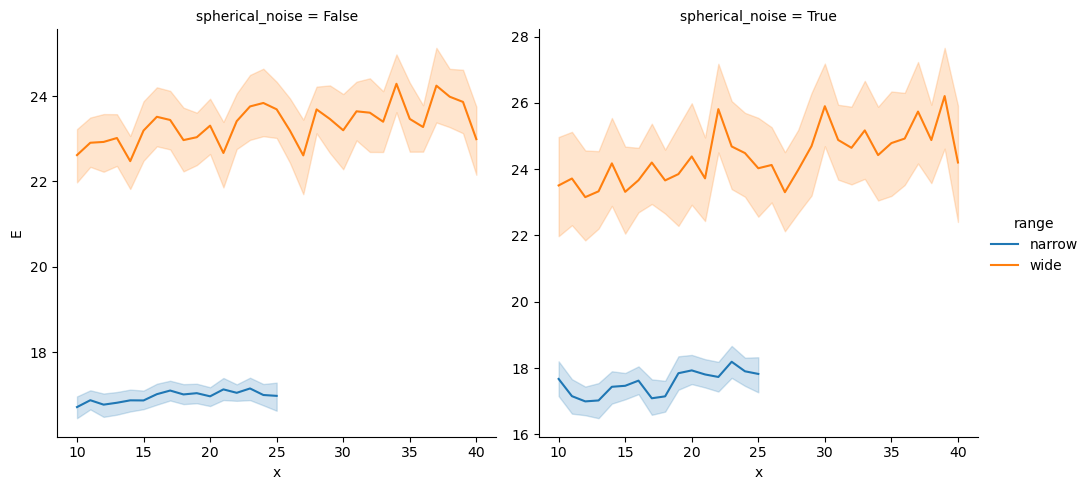

In [13]:


sns.relplot(x='x', y='E', hue='range', col='spherical_noise', data=pars.groupby(['subject','x', 'range', 'spherical_noise'])['E'].mean().reset_index(), kind='line', facet_kws={'sharey': False})

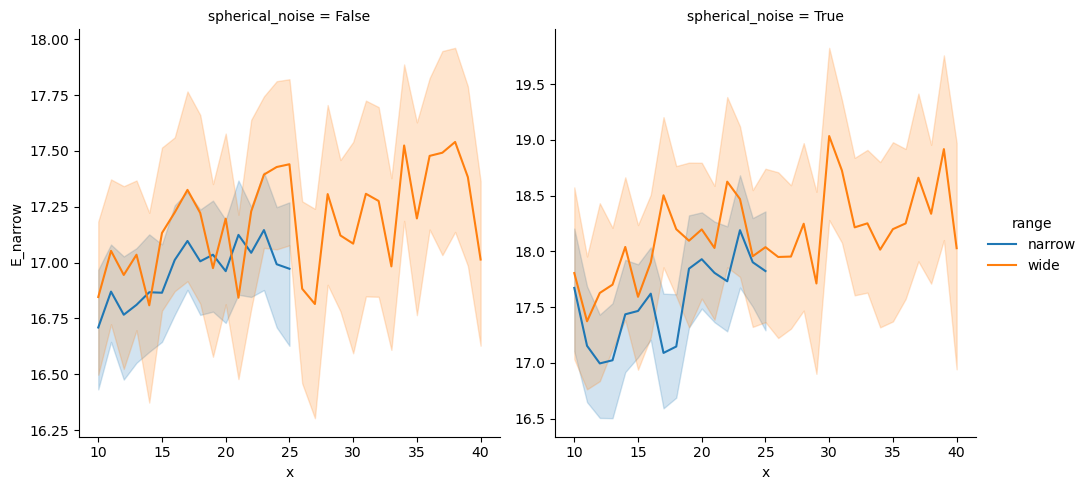

In [15]:


sns.relplot(x='x', y='E_narrow', hue='range', col='spherical_noise', data=pars.groupby(['subject','x', 'range', 'spherical_noise'])['E_narrow'].mean().reset_index(), kind='line', facet_kws={'sharey': False})

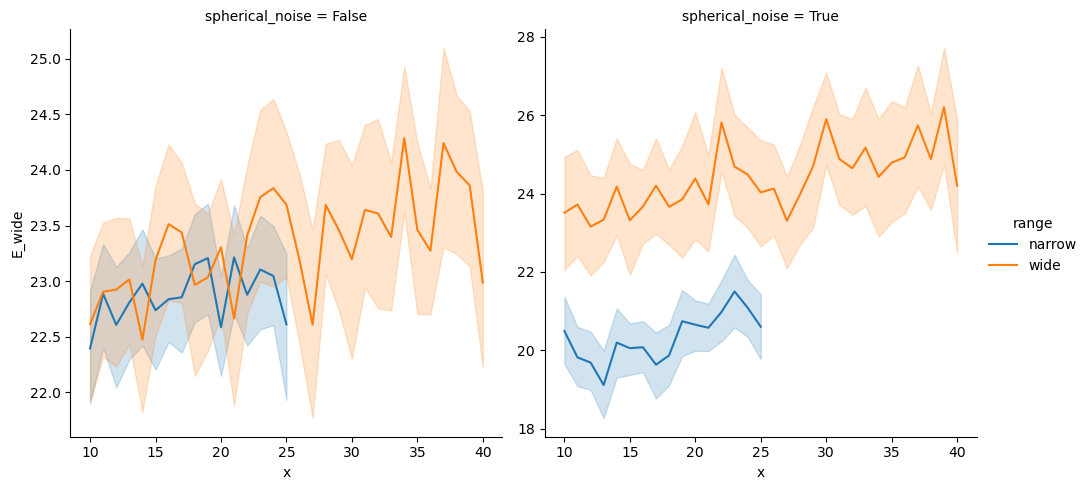

In [16]:


sns.relplot(x='x', y='E_wide', hue='range', col='spherical_noise', data=pars.groupby(['subject','x', 'range', 'spherical_noise'])['E_wide'].mean().reset_index(), kind='line', facet_kws={'sharey': False})

In [21]:
df = get_all_behavioral_data(bids_folder, )
df = df.join(pars[['E', 'sd', 'E_narrow', 'E_wide', 'sd_narrow', 'sd_wide']].droplevel('run2'))
df['E_median_split'] = (
    df.groupby(['subject', 'n', 'range', 'spherical_noise'])['E']
    .transform(lambda x: (x > x.median()).map({True: 'high', False: 'low'}))
)

df['sd_median_split'] = (
    df.groupby(['subject', 'n', 'range', 'spherical_noise'])['sd']
    .transform(lambda x: (x > x.median()).map({True: 'high', False: 'low'}))
)


In [29]:
df.to_csv(bids_folder / 'derivatives' / 'decoding2' / 'decoding_pars.tsv', sep='\t')
pdf.to_csv(bids_folder / 'derivatives' / 'decoding2' / 'decoding_pdf.tsv', sep='\t')

<Axes: xlabel='E_narrow', ylabel='E_wide'>

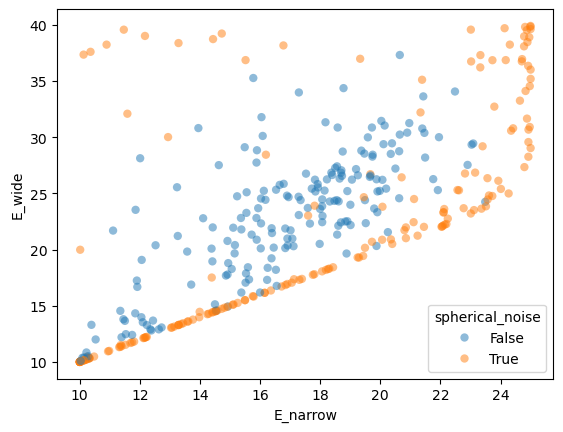

In [35]:
sns.scatterplot(x='E_narrow', y='E_wide', hue='spherical_noise', data=pars.iloc[::100], c='k', alpha=0.5, edgecolor='none', linewidth=0.5)

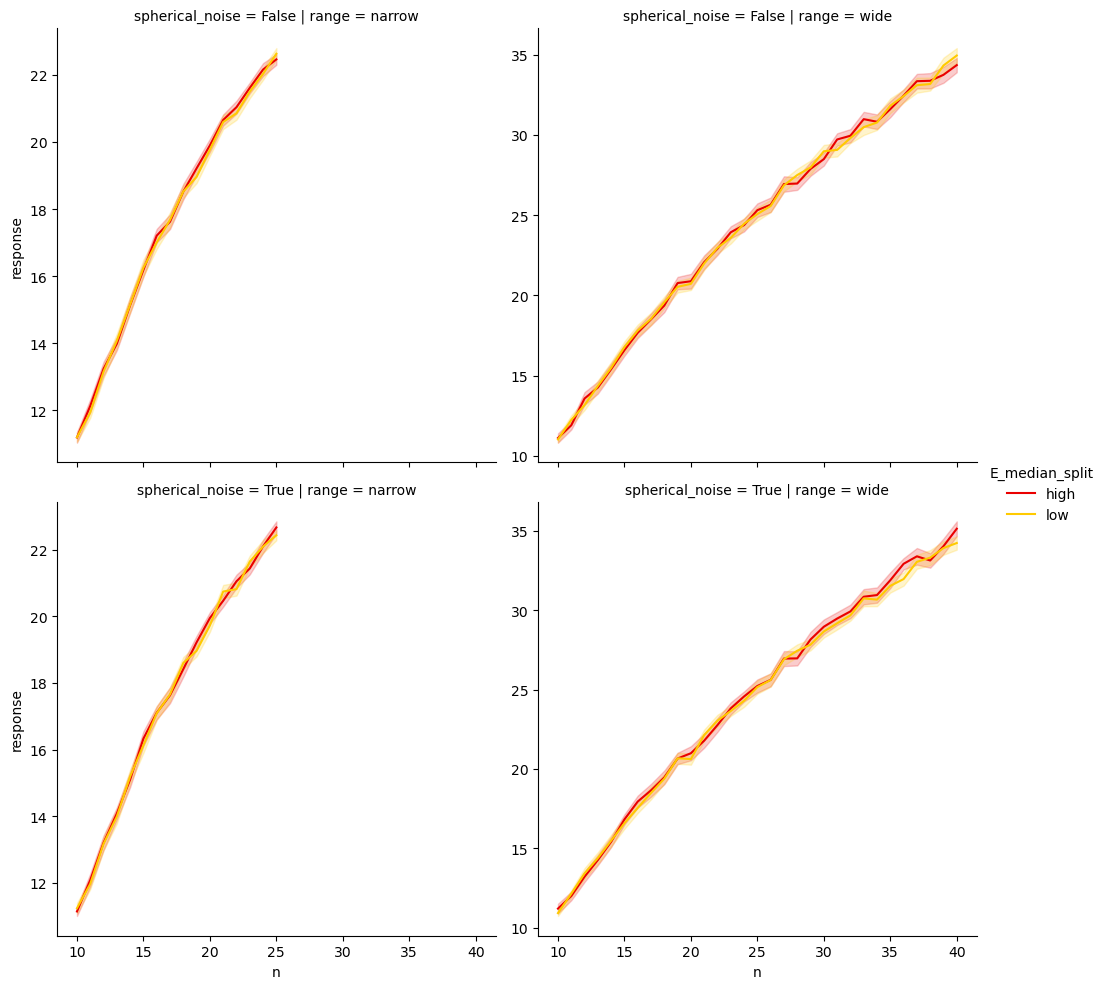

In [22]:
tmp = df.groupby(['subject', 'n', 'range', 'E_median_split', 'spherical_noise'])[['response']].mean()

sns.relplot(
    data=tmp.reset_index(),
    x='n',
    y='response',
    hue='E_median_split',
    col='range',
    row='spherical_noise',
    kind='line',
    errorbar='se',
    palette='hot',
    facet_kws={'sharey': False, 'sharex': True},
)



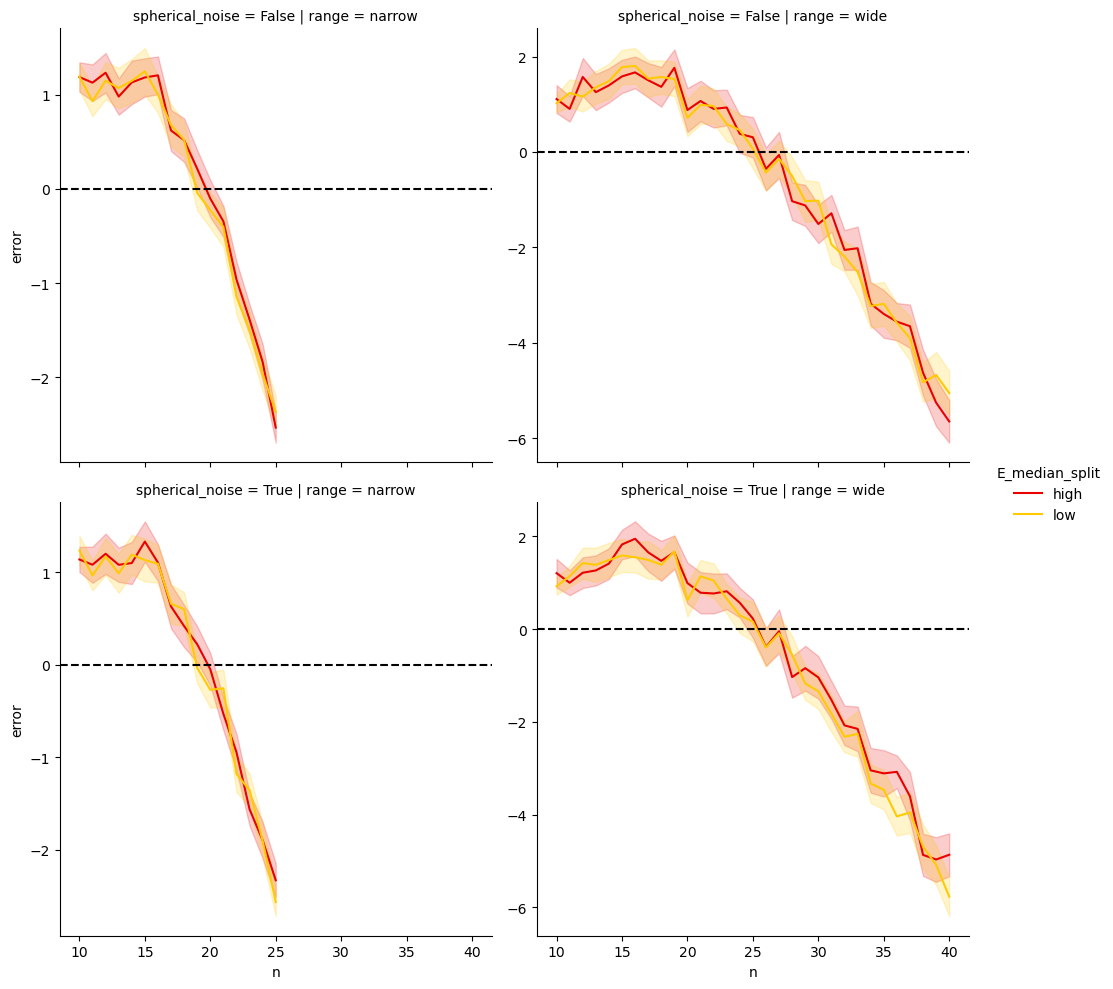

In [23]:
tmp = df.groupby(['subject', 'n', 'range', 'E_median_split', 'spherical_noise'])[['error']].mean()

g = sns.relplot(
    data=tmp.reset_index(),
    x='n',
    y='error',
    hue='E_median_split',
    col='range',
    row='spherical_noise',
    kind='line',
    errorbar='se',
    palette=sns.color_palette('hot', n_colors=2),
    facet_kws={'sharey': False, 'sharex': True},
)

g.map(plt.axhline, y=0, ls='--', c='k')

In [24]:
import pingouin as pg

df.groupby('spherical_noise').apply(
    lambda x: pg.rm_anova(
        data=x.reset_index(),
        dv='error',
        within=['range', 'E_median_split'],
        subject='subject',
        correction=False,
    )
)   

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.d

Source         SS  ddof1  ddof2         MS  \
spherical_noise                                                                 
False           0                   range  22.133447      1     38  22.133447   
                1          E_median_split   0.018316      1     38   0.018316   
                2  range * E_median_split   0.029402      1     38   0.029402   
True            0                   range  21.881866      1     38  21.881866   
                1          E_median_split   0.275517      1     38   0.275517   
                2  range * E_median_split   0.111882      1     38   0.111882   

                           F     p-unc  p-GG-corr       ng2  eps  
spherical_noise                                                   
False           0  22.400526  0.000030   0.000030  0.086413  1.0  
                1   0.266015  0.609006   0.609006  0.000078  1.0  
                2   0.411586  0.525017   0.525017  0.000126  1.0  
True            0  22.185528  0.000033   0.000033  0.085935  1.0  
                1   5.148760  0.029025   0.029025  0.001182  1.0  
                2   2.012401  0.164168   0.164168  0.000480  1.0

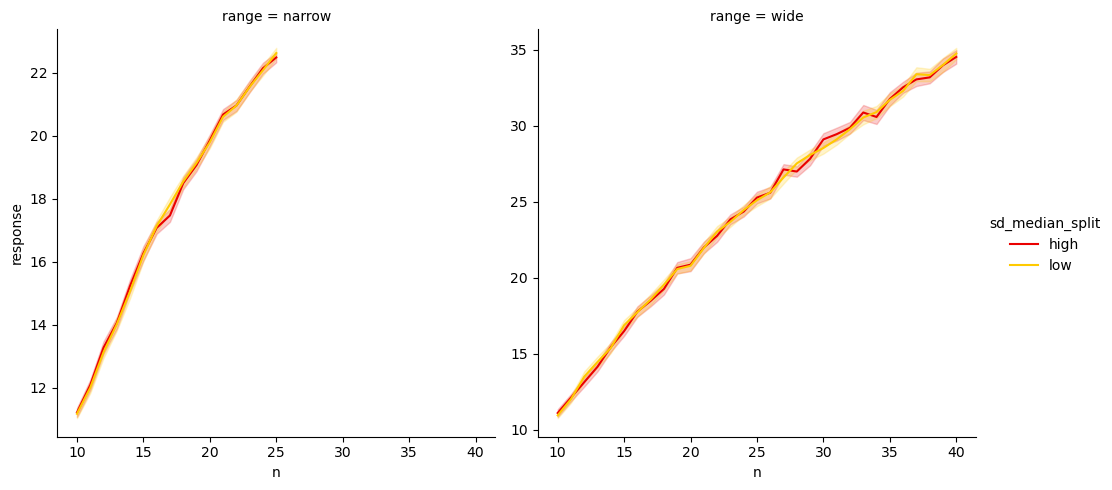

In [25]:
tmp = df.groupby(['subject', 'n', 'range', 'sd_median_split'])[['response']].mean()

sns.relplot(
    data=tmp.reset_index(),
    x='n',
    y='response',
    hue='sd_median_split',
    col='range',
    kind='line',
    errorbar='se',
    palette='hot',
    facet_kws={'sharey': False, 'sharex': True},
)

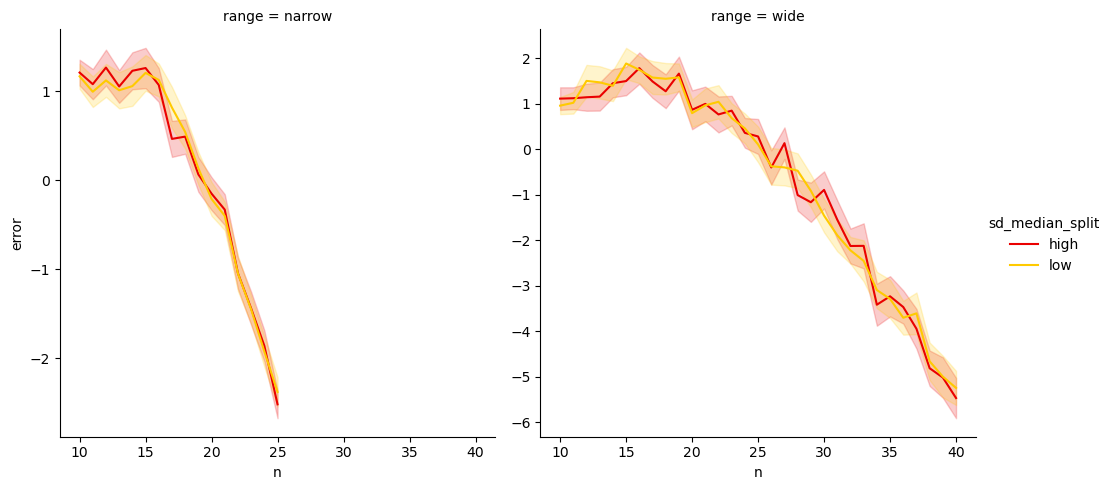

In [26]:
tmp = df.groupby(['subject', 'n', 'range', 'sd_median_split'])[['error']].mean()

sns.relplot(
    data=tmp.reset_index(),
    x='n',
    y='error',
    hue='sd_median_split',
    col='range',
    kind='line',
    errorbar='se',
    palette='hot',
    facet_kws={'sharey': False, 'sharex': True},
)

In [27]:
df.groupby('spherical_noise').apply(
    lambda x: pg.rm_anova(
        data=x.reset_index(),
        dv='error',
        within=['range', 'sd_median_split'],
        subject='subject',
        correction=False,
    )
)   


/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.d

Source         SS  ddof1  ddof2  \
spherical_noise                                                       
False           0                    range  22.255233      1     38   
                1          sd_median_split   0.002009      1     38   
                2  range * sd_median_split   0.042776      1     38   
True            0                    range  21.971321      1     38   
                1          sd_median_split   0.071471      1     38   
                2  range * sd_median_split   0.077856      1     38   

                          MS          F     p-unc  p-GG-corr       ng2  eps  
spherical_noise                                                              
False           0  22.255233  22.523144  0.000029   0.000029  0.086593  1.0  
                1   0.002009   0.020749  0.886227   0.886227  0.000009  1.0  
                2   0.042776   0.544517  0.465099   0.465099  0.000182  1.0  
True            0  21.971321  22.236134  0.000032   0.000032  0.086035  1.0  
                1   0.071471   1.215568  0.277166   0.277166  0.000306  1.0  
                2   0.077856   1.087697  0.303572   0.303572  0.000333  1.0

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_67874/2277416559.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp = df.groupby(['subject', 'range', 'spherical_noise']).apply(lambda x: pg.corr(x['E'], x['response']))
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_67874/2277416559.py:6: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.catplot(x='range', y='r', data=tmp.reset_index(), kind='point', hue='spherical_noise', dodge=.5, markers='o', capsize=.1, errwidth=1.5, errorbar='se')


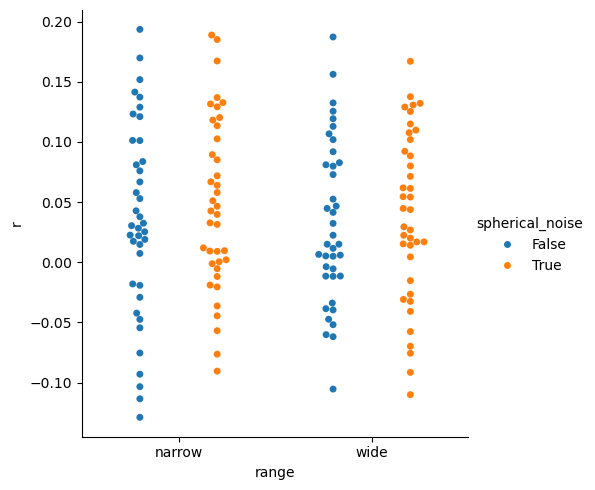

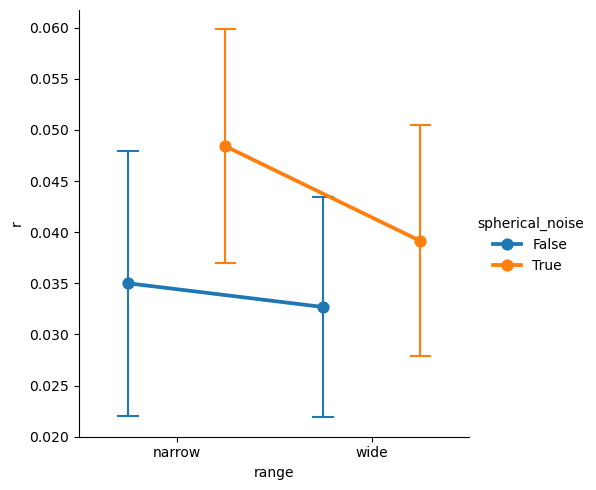

In [28]:
tmp = df.groupby(['subject', 'range', 'spherical_noise']).apply(lambda x: pg.corr(x['E'], x['response']))

sns.catplot(x='range', y='r', data=tmp.reset_index(), kind='swarm', hue='spherical_noise', dodge=.5)

# add mean and error bars
sns.catplot(x='range', y='r', data=tmp.reset_index(), kind='point', hue='spherical_noise', dodge=.5, markers='o', capsize=.1, errwidth=1.5, errorbar='se')